# MVP Notebook

We can call our models in this script, for example here I train the NN model from the script

Accuracy: 0.9561
ROC-AUC:  0.9934

Classification Report:
              precision    recall  f1-score   support

   malignant       0.91      0.98      0.94        42
      benign       0.99      0.94      0.96        72

    accuracy                           0.96       114
   macro avg       0.95      0.96      0.95       114
weighted avg       0.96      0.96      0.96       114



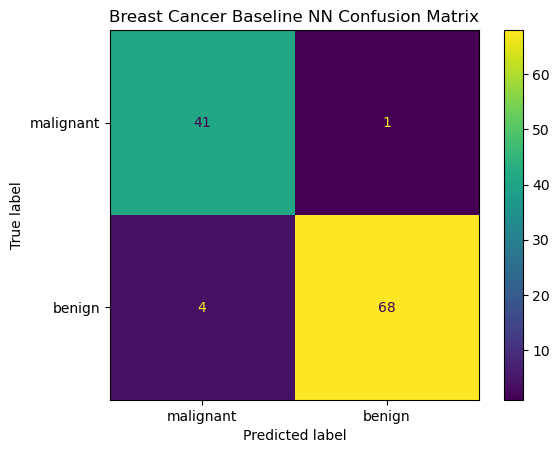

In [3]:
# Add src to path (important!)
import sys
import os

sys.path.append(os.path.abspath("../"))

from src.models.baseline_nn import NeuralNetClassifier

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
)

import matplotlib.pyplot as plt

data = load_breast_cancer()
X, y = data.data, data.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

model = NeuralNetClassifier(
    hidden_dims=[32, 16],
    epochs=100,
    lr=1e-3
)

model.fit(X_train, y_train)

probs = model.predict_proba(X_test)
preds = model.predict(X_test)

acc = accuracy_score(y_test, preds)
auc = roc_auc_score(y_test, probs[:, 1])

print(f"Accuracy: {acc:.4f}")
print(f"ROC-AUC:  {auc:.4f}\n")

print("Classification Report:")
print(classification_report(y_test, preds, target_names=data.target_names))

cm = confusion_matrix(y_test, preds)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=data.target_names
)
disp.plot()
plt.title("Breast Cancer Baseline NN Confusion Matrix")
plt.show()